In [1]:
!pip install gymnasium[classic-control]
#import gymnasium as gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 62.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 72.8 MB/s eta 0:00:00


In [2]:
import gymnasium as gym

In [3]:
env = gym.make("CartPole-v1",render_mode = 'human') 

In [4]:
state = env.reset()[0]
print(f"상태:{state}")
#[카트의 위치, 카트의 속도, 막대의 각도, 막대의 각속도]

action_space = env.action_space
print(f"행동의 차원 수 :{action_space}")
#행동의 차원수: 0-> 왼쪽으로, 1-> 오른쪽으로

상태:[ 0.04098229 -0.0390921  -0.0300123  -0.04140126]
행동의 차원 수 :Discrete(2)


In [5]:
action = 0
next_state, reward, terminated, truncated, info = env.step(action)
'''
next_state : 다음 상태
reward : float 타입 스칼라 값.
terminated : 목표 상태 도달 여부
truncated : 특수 종료 조건 충족 여부
'''
print(next_state)

[ 0.04020045 -0.23377112 -0.03084032  0.24166347]


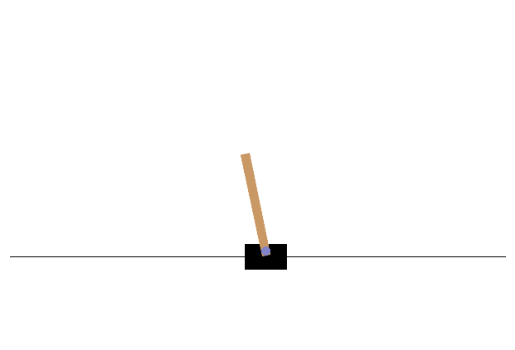

In [6]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

env = gym.make('CartPole-v1', render_mode='rgb_array')
state = env.reset()[0]
done = False

fig, ax = plt.subplots()
img = ax.imshow(env.render())
ax.axis('off')

while not done:
    display.display(plt.gcf())
    display.clear_output(wait=True)
    
    action = np.random.choice([0, 1])
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated | truncated
    
    img.set_data(env.render())

env.close()
plt.close()

In [7]:
from collections import deque
import random
import numpy as np
import gymnasium as gym

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, state, action, reward, next_state, done):
        data = (state, action, reward, next_state, done)
        self.buffer.append(data)

    def __len__(self):
        return len(self.buffer)

    def get_batch(self):
        data = random.sample(self.buffer, self.batch_size)

        state = np.stack([x[0] for x in data])
        action = np.array([x[1] for x in data])
        reward = np.array([x[2] for x in data])
        next_state = np.stack([x[3] for x in data])
        done = np.array([x[4] for x in data]).astype(np.int32) 
        return state, action, reward, next_state, done    

In [11]:
env = gym.make('CartPole-v1', render_mode = 'human')
replay_buffer = ReplayBuffer(buffer_size=10000, batch_size = 32)

for episode in range(10):
    state = env.reset()[0]
    done = False

    while not done:
        action = 0

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated | truncated

        replay_buffer.add(state, action, reward, next_state, done)
        state = next_state

state, action, reward, next_state, done = replay_buffer.get_batch()
print(state.shape)       
print(action.shape)      
print(reward.shape)     
print(next_state.shape) 
print(done.shape)        

(32, 4)
(32,)
(32,)
(32, 4)
(32,)
